## Custom Middleware

In [1]:
import urllib.error
import urllib.request
import pprint
from langchain.tools import tool

from langchain.chat_models import init_chat_model

import langchain_groq
import os

from dotenv import load_dotenv

load_dotenv()


True

In [2]:
model_free = init_chat_model("llama-3.3-70b-versatile",
                        api_key=os.environ["GROQ_API_KEY"],
                        model_provider="groq",
                        # base_url="https://api.groq.com/openai/v1",
                        max_tokens=10000, temperature=0.0)

model_basic = init_chat_model("openrouter/free",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=1000, temperature=0.0)

model_medium = init_chat_model("openai/gpt-5.6-luna",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)

model_advanced = init_chat_model("openai/gpt-5.6-luna-pro",
                        api_key=os.environ["OPENROUTER_API_KEY"],
                        model_provider="openrouter",
                        base_url="https://openrouter.ai/api/v1",
                        max_tokens=10000, temperature=0.0)



In [3]:

# --- Core LangChain ---
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent, AgentState
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver

# --- Middleware building blocks -- every one used in this notebook ---
from langchain.agents.middleware import (
    AgentMiddleware,
    before_model,
    after_model,
    before_agent,
    after_agent,
    wrap_model_call,
    wrap_tool_call,
    hook_config,
    ModelRequest,
    ModelResponse,
)
from typing import Any, Callable
from typing_extensions import NotRequired
from langgraph.runtime import Runtime

`HumanInTheLoopMiddleware` handles approval for any tool. PIIMiddleware handles any of five PII types. CineBot's actual business, though, has rules nothing built-in could know in advance: "no customer books more than 2 movies in one session," "flag it if the bot ever mentions a rival cinema chain by name," "log every cancellation in our own specific audit format." Nothing generic can anticipate rules that are yours alone.

In [5]:
@tool
def check_showtimes(movie_title: str) -> str:
    """Check available showtimes for a movie at the cinema."""
    fake_showtimes = {
        "interstellar": "7:00 PM and 10:15 PM",
        "dune part two": "9:30 PM only",
        "oppenheimer": "Sold out for tonight",
    }
    return fake_showtimes.get(movie_title.lower(), "No showtimes found for that title.")

@tool
def book_seats(movie_title: str, seat_count: int) -> str:
    """Book seats for a movie. Irreversible once confirmed."""
    return f"Booked {seat_count} seat(s) for {movie_title}."

@tool
def cancel_booking(booking_id: str) -> str:
    """Cancel an existing booking. Irreversible."""
    return f"Booking {booking_id} cancelled."

@tool
def get_refund_policy() -> str:
    """Get the cinema's refund policy -- exact wording, not to be paraphrased."""
    return "Refunds available up to 2 hours before showtime. No refunds after that."

cinebot_tools = [check_showtimes, book_seats, cancel_booking, get_refund_policy]

# Callbaks, Hooks, Middleware

Hooks are extension points in custom middleware that let you intercept, inspect, or modify agent execution at specific stages of the lifecycle.

In [7]:
@before_model
def log_before_model(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model."""
    print(f"[LOG] About to call model with {len(state['messages'])} messages so far")
    return None  # None means "observed, nothing to change"


In [8]:
@before_agent
def connecting_to_DB(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model."""
    print(f"I have connected to DB")
    return None  # None means "observed, nothing to change"

In [9]:
@after_agent
def disconnecting_to_DB(state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
    """Log every call about to be made to the model."""
    print(f"I have disconnected to DB")
    return None  # None means "observed, nothing to change"

In [11]:
logged_agent = create_agent(model=model_free, tools=[], middleware=[log_before_model,connecting_to_DB,disconnecting_to_DB])


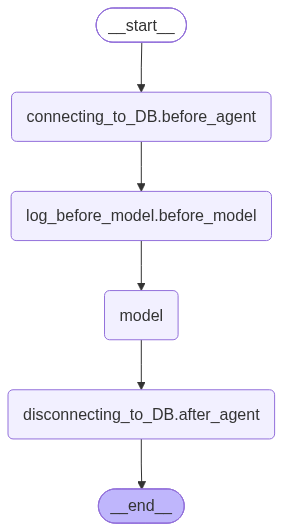

In [12]:
logged_agent

In [13]:
result = logged_agent.invoke({"messages": [("user", "Hi, How are you?")]})

I have connected to DB
[LOG] About to call model with 1 messages so far
I have disconnected to DB


In [ ]:
result

In [ ]:
from rich import print as rprint

In [ ]:
rprint(result)